## Convert DPAM-AI prediction into a library

In [1]:
import os
import sys
import pandas as pd
import numpy as np

root_dir = !git rev-parse --show-toplevel
root_dir = root_dir[0]
os.chdir(root_dir)

In [16]:
# Load the DPAM-AI prediction
df_dpam = pd.read_csv("./output/pacini_domains.csv")
df_dpam.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset
0,P19801,nD1,31-140,1149190,e3hi7A6,243.5.1,0.998,1.0,10.4,0.909,0.909,good_domain,2,5,subset_415
1,P19801,nD2,141-285,1149189,e3hi7A5,243.5.1,0.998,1.0,20.2,0.837,1.198,good_domain,4,5,subset_415
2,P19801,nD3,301-750,1149188,e3hi7A4,12.3.1,1.0,1.0,46.3,0.996,1.601,good_domain,4,25,subset_415
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415


In [3]:
# Add domain_length 
def compute_domain_length(range_str):
    total_length = 0
    for part in range_str.split(','):
        start, end = part.split('-')
        total_length += int(end) - int(start) + 1
    return total_length

df_dpam['domain_length'] = df_dpam['Range'].apply(compute_domain_length)
df_dpam.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length
0,P19801,nD1,31-140,1149190,e3hi7A6,243.5.1,0.998,1.0,10.4,0.909,0.909,good_domain,2,5,subset_415,110
1,P19801,nD2,141-285,1149189,e3hi7A5,243.5.1,0.998,1.0,20.2,0.837,1.198,good_domain,4,5,subset_415,145
2,P19801,nD3,301-750,1149188,e3hi7A4,12.3.1,1.0,1.0,46.3,0.996,1.601,good_domain,4,25,subset_415,450
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415,65
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415,60


In [4]:
import math
# Compute the number of domains in each Twist synthesis bin
twist_bin_DNA = [0, 300, 500, 1800, 5000, np.inf]
overhang = 42

twist_bin_protein = []
for dna in twist_bin_DNA:
    if np.isinf(dna):
        twist_bin_protein.append(np.inf)
    else:
        twist_bin_protein.append(math.floor((dna - overhang) / 3))
twist_bin_protein

[-14, 86, 152, 586, 1652, inf]

In [6]:
# Determine the bin for each domain
df_dpam['bin'] = pd.cut(df_dpam['domain_length'], bins=twist_bin_protein, labels=range(len(twist_bin_protein)-1))

# Summarize the number of domains in each bin, and the sum of domain_length in each bin
df_summary = df_dpam.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()
# rename the columns
df_summary.rename(columns={'Domain': 'n_domains', 'domain_length': 'sum_protein_length'}, inplace=True)
df_summary['sum_DNA_length'] = df_summary['sum_protein_length'] * 3
df_summary['min_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x])
df_summary['max_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x+1])
df_summary.head()


/tmp/ipykernel_185866/2597099056.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_dpam.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()


,bin,n_domains,sum_protein_length,sum_DNA_length,min_DNA,max_DNA
0,0,1043,52711,158133,0,300.0
1,1,949,109226,327678,300,500.0
2,2,1223,331628,994884,500,1800.0
3,3,70,64944,194832,1800,5000.0
4,4,0,0,0,5000,inf


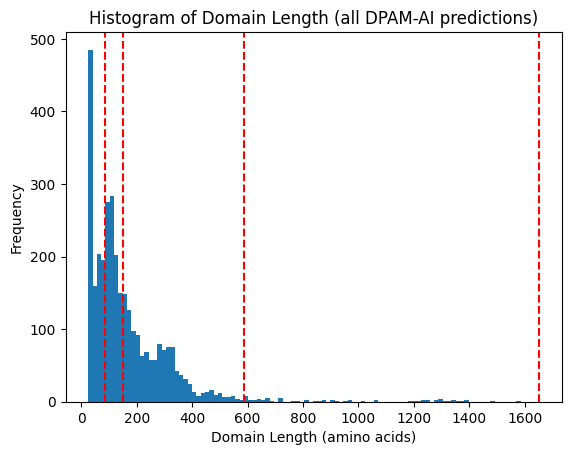

In [7]:
# Plot histogram of domain_length
import matplotlib.pyplot as plt

plt.hist(df_dpam['domain_length'], bins=100)

# Draw vertical lines at bin boundaries
for i in range(len(twist_bin_protein)):
    if i > 0 and i < 5000:
        plt.axvline(x=twist_bin_protein[i], color='red', linestyle='--')

plt.xlabel('Domain Length (amino acids)')
plt.ylabel('Frequency')
plt.title('Histogram of Domain Length (all DPAM-AI predictions)')
plt.show()


In [81]:
# Function to return the protein sequence of a .pdb file between resi_start and resi_end using Biopython
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import protein_letters_3to1
parser = PDBParser(QUIET=True)

def get_protein_sequence(struct, resi_start, resi_end, chain_id=None):
    # Assume 1st model
    model = struct[0]
    # Default to the first chain if chain_id is not specified
    chains = list(model.get_chains())
    if chain_id is None:
        chain = chains[0]
    else:
        chain = model[chain_id]

    residues_in_range = [res for res in chain if res.id[1] >= resi_start and res.id[1] <= resi_end]
    # Build the sequence from residues in range
    seq = ""
    for res in residues_in_range:
        if 'CA' in res and res.resname in protein_letters_3to1:
            seq += protein_letters_3to1[res.resname]
    return seq

row = df_dpam.iloc[0]
subset = row['subset']
protein = row['Protein']
pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
struct = parser.get_structure('protein', pdb_file)
get_protein_sequence(struct, 1, 100)


'MPALGWAVAAILMLQTAMAEPSPGTLPRKAGVFSDLSNQELKAVHSFLWSKKELRLQPSSTTTMAKNTVFLIEMLLPKKYHVLRFLDKGERHPVREARAV'

In [10]:
# ------ Helper functions to compute intracellular percentage ------

from Bio import pairwise2

# Compute intracellular_percentage using deepTMHMM annotation
deepTMHMM_dir = "/work/upthomae/Meng/hp_list_DeepTMHMM/out/"

# Function to get the deepTMHMM topology of a protein sequence and percentage identity from alignment
def get_deepTMHMM_topology(protein_sequence, uniprot_id, deepTMHMM_dir):
    # Construct the path to the .3line file
    three_line_file = os.path.join(deepTMHMM_dir, uniprot_id, "predicted_topologies.3line")

    # Load the .3line file: 1st line is header, 2nd is full sequence, 3rd is topology
    with open(three_line_file, "r") as f:
        lines = [l.strip() for l in f.readlines()]
    full_seq_3line = lines[1]
    topology_3line = lines[2]

    # Find the best local alignment of protein_sequence within full_seq_3line

    aln = pairwise2.align.localms(
        full_seq_3line, protein_sequence,
        2,   # match
        -1,  # mismatch
        -1,  # gap open
        -0.1,# gap extend
        one_alignment_only=True
    )

    # Extract the aligned region indices in full_seq_3line and compute percent identity
    if aln:
        a = aln[0]
        aln_start = a.start
        aln_end = a.end    # exclusive

        # Extract part of full_seq_3line that matches protein_sequence
        matched_full_seq = full_seq_3line[aln_start:aln_end]
        matched_topology = topology_3line[aln_start:aln_end]

        # Calculate percent identity on the aligned region
        aligned_query = a.seqB[a.start:a.end]
        identities = sum(aa1 == aa2 for aa1, aa2 in zip(matched_full_seq, aligned_query))
        percent_identity = 100.0 * identities / len(matched_full_seq) if matched_full_seq else 0.0
    else:
        matched_full_seq = ""
        matched_topology = ""
        percent_identity = 0.0

    return matched_full_seq, matched_topology, percent_identity


# #

# Function to compute the percentage of intracellular residues in matched_topology (not O or M)
def compute_intracellular_percentage(topology):
    if not topology:
        return 0.0
    non_o_m = sum(1 for t in topology if t not in ('O', 'M'))
    return 100.0 * non_o_m / len(topology)

/home/ymeng/miniconda3/envs/MaSIF/lib/python3.11/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [82]:
# Workflow to compute intracellular percentage from a row of df_dpam
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)

def calc_intracellular_percentage_from_row(row, root_dir, deepTMHMM_dir, debug=False):
    """
    Given a row from df_dpam, return intracellular_percentage for the domain.
    Optionally print debugging messages if debug=True.
    Handles domains with potential gaps (comma-separated ranges).
    Tries to catch edge case errors (such as file not found, alignment failure)
    by imputing 1 for intracellular_percentage.
    """
    try:
        subset = row['subset']
        protein = row['Protein']
        range_str = row['Range']
        
        # Handle gap in range_str by splitting range_str into ranges
        ranges = range_str.split(',')

        all_protein_seqs = []
        all_matched_full_seqs = []
        all_matched_topologies = []
        percent_identities = []

        for segment in ranges:
            seg = segment.strip()
            resi_start, resi_end = int(seg.split('-')[0]), int(seg.split('-')[1])
            pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
            struct = parser.get_structure('protein', pdb_file)
            protein_sequence = get_protein_sequence(struct, resi_start, resi_end)
            matched_full_seq, matched_topology, percent_identity = get_deepTMHMM_topology(
                protein_sequence, protein, deepTMHMM_dir
            )
            all_protein_seqs.append(protein_sequence)
            all_matched_full_seqs.append(matched_full_seq)
            all_matched_topologies.append(matched_topology)
            percent_identities.append(percent_identity)
        
        # Calculate total percent identity for the overall domain by weighted averaging by length
        total_length = sum(len(seq) for seq in all_matched_full_seqs if seq)
        if total_length > 0:
            weighted_identity = sum(
                percent_identity * len(seq) for percent_identity, seq in zip(percent_identities, all_matched_full_seqs) if seq
            ) / total_length
        else:
            weighted_identity = 0.0

        if weighted_identity < 0.8:
            if debug:
                print(f"Warning: Weighted percent identity {weighted_identity}% is less than 80%, imputing intracellular percentage to 1")
            intracellular_percentage = 1
        else:
            # Concatenate matched_topology for all segments and compute intracellular percentage
            topology_concat = "".join(all_matched_topologies)
            intracellular_percentage = compute_intracellular_percentage(topology_concat)

        if debug:
            print("pdb_file:", pdb_file)
            print("protein_sequences:", all_protein_seqs)
            print("matched_full_seqs:", all_matched_full_seqs)
            print("matched_topologies:", all_matched_topologies)
            print("Percent identities:", percent_identities)
            print("Weighted percent identity: {:.2f}%".format(weighted_identity))
            print("Intracellular percentage: {:.2f}%".format(intracellular_percentage))

        return intracellular_percentage

    except Exception as e:
        print("Exception occurred in calc_intracellular_percentage_from_row:", e)
        import traceback
        traceback.print_exc()
        print("Imputing intracellular percentage to 1 due to error.")
        return 1

# Test it on a row with gap (Range contains comma)
row = df_dpam[df_dpam['Range'].str.contains(',')].iloc[0]
print(row)
calc_intracellular_percentage_from_row(row, root_dir, deepTMHMM_dir, debug=True)

Protein                              P49915
Domain                                  nD2
Range                       216-485,491-693
ECOD_num                            2832076
ECOD_key                            e7mo6B3
T-group                            2005.1.1
DPAM_prob                             0.992
HH_prob                                 1.0
DALI_zscore                            19.6
Hit_cov                               0.933
Tgroup_cov                             2.21
Judge                           good_domain
Hcount                                   15
Scount                                   13
subset                            subset_88
domain_length                           473
bin                                       2
intracellular_percentage              100.0
Name: 31, dtype: object
pdb_file: /scratch/ymeng/DPAM/pacini_results/step2/subset_88/P49915.pdb
protein_sequences: ['TFTVQNRELECIREIKERVGTSKVLVLLSGGVDSTVCTALLNRALNQEQVIAVHIDNGFMRKRESQSVEEALKKLGIQVKVINAAHSFYNG

100.0

In [12]:
# Apply calc_intracellular_percentage_from_row to df_dpam
df_dpam['intracellular_percentage'] = df_dpam.apply(lambda row: calc_intracellular_percentage_from_row(row, root_dir, deepTMHMM_dir, debug=False), axis=1)
df_dpam.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length,bin,intracellular_percentage
0,P19801,nD1,31-140,1149190,e3hi7A6,243.5.1,0.998,1.0,10.4,0.909,0.909,good_domain,2,5,subset_415,110,1,0.0
1,P19801,nD2,141-285,1149189,e3hi7A5,243.5.1,0.998,1.0,20.2,0.837,1.198,good_domain,4,5,subset_415,145,1,0.0
2,P19801,nD3,301-750,1149188,e3hi7A4,12.3.1,1.0,1.0,46.3,0.996,1.601,good_domain,4,25,subset_415,450,2,0.0
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415,65,0,100.0
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415,60,0,100.0


In [13]:
# write df_dpam to csv
df_dpam.to_csv("./output/pacini_domains_deepTMHMM.csv", index=False)


In [90]:
df_dpam = pd.read_csv("./output/pacini_domains_deepTMHMM.csv")

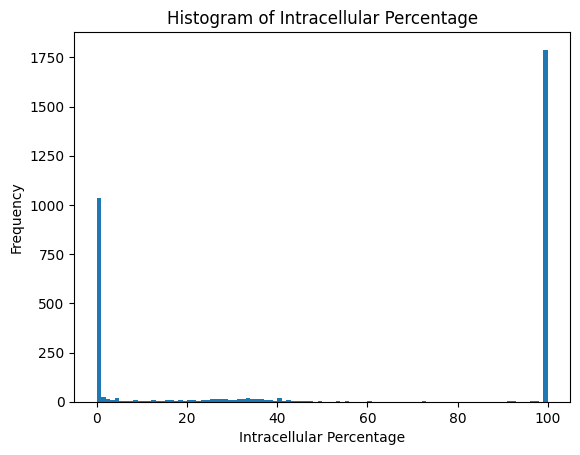

In [91]:
# plot histogram of intracellular_percentage
plt.hist(df_dpam['intracellular_percentage'], bins=100)
plt.xlabel('Intracellular Percentage')
plt.ylabel('Frequency')
plt.title('Histogram of Intracellular Percentage')
plt.show()


In [92]:
# Filter out poor quality domains
df_dpam_filtered = df_dpam.copy()
n_row_total = df_dpam_filtered.shape[0]
print(f"Before filtering: {n_row_total}")

# Remove rows where DPAM_prob is na
df_dpam_filtered = df_dpam_filtered[df_dpam_filtered['DPAM_prob'] != "na"]

n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where DPAM_prob is na")

# Convert numeric columns to float
df_dpam_filtered['DPAM_prob'] = df_dpam_filtered['DPAM_prob'].astype(float)
df_dpam_filtered['intracellular_percentage'] = df_dpam_filtered['intracellular_percentage'].astype(float)

# 1. Remove entries where judge is simple_topology AND DPAM_prob < 0.98
df_dpam_filtered = df_dpam_filtered[
    (df_dpam_filtered['Judge'] != 'simple_topology') | 
    (df_dpam_filtered['DPAM_prob'] >= 0.98)
]
n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where Judge is simple_topology and DPAM_prob < 0.98")

# 2. Remove entries where low_confidence judge
df_dpam_filtered = df_dpam_filtered[
    (df_dpam_filtered['Judge'] != 'low_confidence')
]
n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where Judge is low_confidence")

# 3. Remove non-intracellular domains (intracellular_percentage < 50)
df_dpam_filtered = df_dpam_filtered[
    (df_dpam_filtered['intracellular_percentage'] >= 50)
]
n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where intracellular_percentage < 50")

print(f"Before filtering: {df_dpam.shape}")
print(f"After filtering: {df_dpam_filtered.shape}")

Before filtering: 3285
Removed 34 rows where DPAM_prob is na
Removed 341 rows where Judge is simple_topology and DPAM_prob < 0.98
Removed 373 rows where Judge is low_confidence
Removed 1713 rows where intracellular_percentage < 50
Before filtering: (3285, 18)
After filtering: (1572, 18)


In [93]:
# Determine the bin for each domain
df_dpam_filtered['bin'] = pd.cut(df_dpam_filtered['domain_length'], bins=twist_bin_protein, labels=range(len(twist_bin_protein)-1))

# Summarize the number of domains in each bin, and the sum of domain_length in each bin
df_summary = df_dpam_filtered.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()
# rename the columns
df_summary.rename(columns={'Domain': 'n_domains', 'domain_length': 'sum_protein_length'}, inplace=True)
df_summary['sum_DNA_length'] = df_summary['sum_protein_length'] * 3
df_summary['min_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x])
df_summary['max_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x+1])
df_summary.head()

/tmp/ipykernel_185866/2364061194.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_dpam_filtered.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()


,bin,n_domains,sum_protein_length,sum_DNA_length,min_DNA,max_DNA
0,0,331,19626,58878,0,300.0
1,1,496,58063,174189,300,500.0
2,2,708,193345,580035,500,1800.0
3,3,37,29171,87513,1800,5000.0
4,4,0,0,0,5000,inf


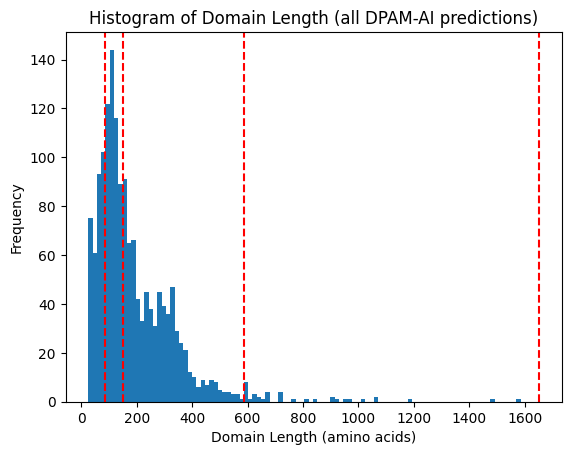

In [94]:
# Plot histogram of domain_length
import matplotlib.pyplot as plt

plt.hist(df_dpam_filtered['domain_length'], bins=100)

# Draw vertical lines at bin boundaries
for i in range(len(twist_bin_protein)):
    if i > 0 and i < 5000:
        plt.axvline(x=twist_bin_protein[i], color='red', linestyle='--')

plt.xlabel('Domain Length (amino acids)')
plt.ylabel('Frequency')
plt.title('Histogram of Domain Length (all DPAM-AI predictions)')
plt.show()


_______
### Handle gaps in sequence

In [95]:
# -------- Functions to deal with gaps in domain ranges --------

# Function to return the number of gaps (count commas)
def num_gaps(range_str):
    return range_str.count(',')

#num_gaps('1-10,15-20,25-30') 


# Function to compute the length of the domain (with gaps)
def domain_length_gap(range_str):
    """
    Calculate the total length of a domain by summing the lengths of all its fragments.

    Args:
        range_str (str): A string representing the domain range, e.g., "1-10,15-20"
        
    Returns:
        int: The total length of the domain
    """
    # Split the range string into individual ranges
    ranges = [tuple(map(int, frag.split('-'))) for frag in range_str.split(',')]
    
    # Calculate the total length of the domain
    total_length = sum(end - start + 1 for start, end in ranges)

    return total_length

# print(domain_length_gap('1-10,16-20,26-30'))
# Returns 20

# Function to compute the total length of the domain (continuous)
def domain_length_continuous(range_str):
    """
    Calculate the total length of a domain from the residue with lowest index to the residue with highest index
    across all fragments in the range string.

    Args:
        range_str (str): A string representing the domain range, e.g., "1-10,15-20"

    Returns:
        int: The total (continuous) length of the domain
    """
    # Split the range string into fragments
    fragments = range_str.split(',')
    starts = []
    ends = []
    for frag in fragments:
        frag = frag.strip()
        if '-' in frag:
            start_str, end_str = frag.split('-')
            starts.append(int(start_str))
            ends.append(int(end_str))
        else:
            # In case there is a single residue, e.g., "42"
            starts.append(int(frag))
            ends.append(int(frag))
    min_start = min(starts)
    max_end = max(ends)
    return max_end - min_start + 1

print(domain_length_continuous('1-10,16-20,26-30'))
# Returns 30

30


In [97]:
# Apply gap_length and num_gaps to df_domains
# df_dpam_filtered['domain_length_gap'] = df_dpam_filtered['Range'].apply(domain_length_gap)
# df_dpam_filtered['domain_length_continuous'] = df_dpam_filtered['Range'].apply(domain_length_continuous)
# df_dpam_filtered['gap_length'] = df_dpam_filtered['domain_length_continuous'] - df_dpam_filtered['domain_length_gap']
df_dpam_filtered['num_gaps'] = df_dpam_filtered['Range'].apply(num_gaps)

df_dpam_filtered.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415,65,0,100.0,0
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415,60,0,100.0,0
5,P05771,nD3,156-290,179750,e3pfqA2,11.2.1,0.998,1.0,26.1,0.971,0.957,good_domain,3,7,subset_415,135,1,100.0,0
6,P05771,nD4,326-665,1397996,e4ra5A1,206.1.1,0.999,1.0,46.6,0.97,1.13,good_domain,11,8,subset_415,340,2,100.0,0
8,Q9GZQ8,nD1,1-120,2628875,e7brnA1,221.1.1,0.997,1.0,18.4,0.872,1.277,good_domain,4,6,subset_98,120,1,100.0,0


In [98]:
# subset to only those with gaps
df_dpam_gap = df_dpam_filtered[df_dpam_filtered['num_gaps'] > 0]
df_dpam_gap.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps
31,P49915,nD2,"216-485,491-693",2832076,e7mo6B3,2005.1.1,0.992,1.0,19.6,0.933,2.21,good_domain,15,13,subset_88,473,2,100.000000,1
46,Q6ISB3,nD1,"246-435,466-485",2387776,e5mphA1,11.1.5,0.997,1.0,30.4,0.833,1.364,good_domain,4,11,subset_115,210,2,100.000000,1
58,P36888,nD5,"436-565,576-715,771-960",1871755,e5k5xA1,206.1.1,0.992,0.999,45.5,0.939,1.528,good_domain,12,18,subset_1,460,2,72.391304,2
65,Q13003,nD5,"556-660,816-870",2816920,e7f57A3,5054.1.1,0.987,1.0,12.3,0.528,0.702,good_domain,5,3,subset_1,160,2,53.125000,1
74,P21860,nD5,"661-680,701-1003",379980,e3kexA1,206.1.1,0.990,1.0,40.4,0.936,1.073,good_domain,12,9,subset_84,323,2,98.761610,1


In [99]:
# Parameters to handle gaps
min_gap_size = 20
median_linker_length_ref_csv = "./notebooks/median_linker_length.csv"

In [100]:
# Determine the bin for each domain
df_dpam['bin'] = pd.cut(df_dpam['domain_length'], bins=twist_bin_protein, labels=range(len(twist_bin_protein)-1))

# Summarize the number of domains in each bin, and the sum of domain_length in each bin
df_summary = df_dpam.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()
# rename the columns
df_summary.rename(columns={'Domain': 'n_domains', 'domain_length': 'sum_protein_length'}, inplace=True)
df_summary['sum_DNA_length'] = df_summary['sum_protein_length'] * 3
df_summary['min_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x])
df_summary['max_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x+1])
df_summary.head()


/tmp/ipykernel_185866/2597099056.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_dpam.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()


,bin,n_domains,sum_protein_length,sum_DNA_length,min_DNA,max_DNA
0,0,1043,52711,158133,0,300.0
1,1,949,109226,327678,300,500.0
2,2,1223,331628,994884,500,1800.0
3,3,70,64944,194832,1800,5000.0
4,4,0,0,0,5000,inf


In [ ]:
# # --------- Helper functions to graft GS linker to bridge gaps ---------

# # Function to return the CA coordinate of a residue in a struct
# def get_CA_coord(struct, resi, chain=None):
#     """
#     Get the CA coordinate of a residue in a structure.
    
#     Args:
#         struct: Bio.PDB.Structure.Structure object
#         resi: Residue number (int)
#         chain: Bio.PDB.Chain object (optional, assume the first chain if not specified)

#     Returns:
#         tuple: (x, y, z) coordinates of the CA atom
#     """
#     if chain is None:
#         chain = list(struct.get_chains())[0]
#     for residue in chain:
#         if residue.id[1] == resi:
#             return residue['CA'].get_coord()
#     return None

# # get_CA_coord(struct, 42, chain=None)

# # Function to determine the length and sequence of the GS linker based on the distance between the CA atoms of the two residues
# # Requires a reference table
# df_median_linker_length = pd.read_csv(median_linker_length_ref_csv)

# def get_GS_linker(dist, df_median_linker_length):
#     """
#     Get the GS linker sequence and length based on the distance between the CA atoms of the two residues
#     """
#     # Find the the first row where calpha_dist is greater than dist
#     row = df_median_linker_length[df_median_linker_length['calpha_dist'] > dist].iloc[0]
#     linker_length = int(row['seq_dist'])

#     # Return linker sequence based on linker_length
#     linker_seq = ""
#     if linker_length == 2:
#         linker_seq = "GG"
#     elif linker_length == 3:
#         linker_seq = "GSG"
#     elif linker_length == 4:
#         linker_seq = "GSSG"
#     elif linker_length >= 5:
#         # For linker_length >= 5, repeat GGSS so that first and last residues are G
#         core_repeat = "GGSS"
#         # First add 1 G at start
#         linker_seq = "G"
#         # Number of residues already added
#         residues = 1
#         while residues + 4 <= linker_length:
#             linker_seq += core_repeat
#             residues += 4
#         # Fill up to needed length with Gs, but last residue must be G
#         while residues < linker_length - 1:
#             linker_seq += "G"
#             residues += 1
#         # Last residue is G
#         linker_seq += "G"

#         # Replace "GGG" with "GSG"
#         linker_seq = linker_seq.replace("GGG", "GSG")
#     return linker_seq

# get_GS_linker(40, df_median_linker_length)
    

'GSGSSGGSSGGSSGGSSG'

In [ ]:
# from Bio.PDB import PDBParser

# # --------- Workflow to graft GS linker to bridge gaps ---------

# # Function to graft GS linkers to bridge gaps in a protein domain specified by range_str.
# # Including the handling of min_gap_size.
# def graft_GS_linkers(range_str, subset, protein, min_gap_size=None):
#     """
#     Graft GS linkers to bridge gaps in a protein domain specified by range_str.
#     Arguments:
#         range_str (str): Comma-separated list of residue ranges for fragments (e.g., "51-90,126-135,...").
#         subset (str): Subset folder identifier to find the PDB file.
#         protein (str): UniProt protein accession or identifier.
#         min_gap_size (int): Minimum gap size to graft a GS linker. 
#                             Gap below this size will be filled with uniprot sequence.
#                             (Default: None, always try to graft GS linker)
#     Returns:
#         linker_seqs (str or None): Comma-separated GS/uniprot linker sequences for each gap, or None if single fragment.
#         linker_types (str or None): Comma-separated type labels ("GS" or "uniprot") for each linker, or None if single fragment.
#         full_seq (str): Full concatenated sequence of all fragments and linkers.
#     """
#     pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
#     parser = PDBParser(QUIET=True)
#     struct = parser.get_structure('protein', pdb_file)

#     fragments = range_str.split(',')

#     # Handle case where range_str contains only one fragment
#     if len(fragments) == 1:
#         frag_start, frag_end = map(int, fragments[0].strip().split('-'))
#         full_seq = get_protein_sequence(struct, frag_start, frag_end)
#         linker_seqs = None
#         linker_types = None
#         return linker_seqs, linker_types, full_seq

#     linker_seqs = []
#     linker_types = []
#     full_seqs = []
    
#     for i in range(len(fragments)-1):
#         frag_i = fragments[i].strip()
#         frag_i_start, frag_i_end = map(int, frag_i.split('-'))
#         frag_next = fragments[i+1].strip()
#         frag_next_start, frag_next_end = map(int, frag_next.split('-'))

#         # Add the sequence of this fragment to full_seqs before each linker (first fragment or merged case)
#         full_seqs.append(get_protein_sequence(struct, frag_i_start, frag_i_end))

#         # Get the gap length
#         gap_length = frag_next_start - frag_i_end

#         # Logic to handle min_gap_size: if gap is smaller than min_gap_size, fill with uniprot seq, otherwise determine
#         # whether to use GS linker or uniprot as usual
#         if (min_gap_size is not None) and (gap_length < min_gap_size):
#             # Fill gap with uniprot sequence (no GS linker)
#             gap_resi_start = frag_i_end + 1
#             gap_resi_end = frag_next_start - 1
#             if gap_resi_start <= gap_resi_end:
#                 linker_seq = get_protein_sequence(struct, gap_resi_start, gap_resi_end)
#             else:
#                 linker_seq = ""
#             linker_type = "uniprot"
#         else:
#             # Standard GS linker logic
#             # Get the CA coordinates
#             frag_i_end_CA_coord = get_CA_coord(struct, frag_i_end)
#             frag_next_start_CA_coord = get_CA_coord(struct, frag_next_start)
#             # Compute Euclidean distance between the two CA coordinates
#             dist = np.linalg.norm(np.array(frag_i_end_CA_coord) - np.array(frag_next_start_CA_coord))
            
#             # Get the GS linker sequence
#             linker_seq = get_GS_linker(dist, df_median_linker_length)
#             linker_type = "GS"

#             # Compare the length of the GS linker with the length of the gap
#             if gap_length > 0:  # Avoid division by zero, in theory
#                 if len(linker_seq)/gap_length > 0.5:
#                     gap_resi_start = frag_i_end + 1
#                     gap_resi_end = frag_next_start - 1
#                     if gap_resi_start <= gap_resi_end:
#                         linker_seq = get_protein_sequence(struct, gap_resi_start, gap_resi_end)
#                     else:
#                         linker_seq = ""
#                     linker_type = "uniprot"
        
#         linker_seqs.append(linker_seq)
#         linker_types.append(linker_type)
#         # Add the linker sequence to full_seqs
#         full_seqs.append(linker_seq)

#     # Add the sequence of the last fragment
#     frag_last_start, frag_last_end = map(int, fragments[-1].strip().split('-'))
#     full_seqs.append(get_protein_sequence(struct, frag_last_start, frag_last_end))

#     # Combine full_seqs into a single string
#     linker_seqs_str = ",".join(linker_seqs)
#     linker_types_str = ",".join(linker_types)
#     full_seq = "".join(full_seqs)
#     return linker_seqs_str, linker_types_str, full_seq

# # Example usage:
# row = df_dpam_gap[(df_dpam_gap["Protein"] == "Q96N67") & (df_dpam_gap["Domain"] == "nD3")].iloc[0]
# linker_seqs, linker_types, full_seq = graft_GS_linkers(row['Range'], row['subset'], row['Protein'])

# print(f"Linker sequences: {linker_seqs}")
# print(f"Linker types: {linker_types}")
# print(f"Full sequence: {full_seq}")

Linker sequences: GSG,GSGSSGGSSGGSSGGSSG,GSGSSG,GSGSSG,GSGSSG,GSGSSG
Linker types: GS,GS,GS,GS,GS,GS
Full sequence: LTEAVDPVDLEDYLITHPLAVDSGPLRDLIEFPPDDIEVVGSGIVIRKYHKLGGSGSSGGSSGGSSGGSSGRDVYVPNTTYGSGSSGHTQDPYLDKFFALVNALDEHLFPVRIGDMRIMENNLENELKSSISALNSSQLEPVVRFLHLLLDKLILLVIRPPVIAGQIVNLGQASFEAMASIINRLHKNLEGNHDQHGRNSLLASYIHYVFRLGSGSSGHEELALQWVVCSGSVRESALQQAWFFFELMVKSMVHHLYFNDKLEAPRKSRFPERFMDDIAALVSTIASDIVSRFQKDTEMVERLNTSLAFFLNDLLSVMDRGFVFSLIKSCYKQVSSKLYSLPNPSVLVSLRLDFLRIICSHEHYVTLNLPCSLGSGSSGANMFELSVPFRQQHYLAGLVLTELAVILDPDAEGLFGLHKKVINMVHNLLSSHDSDPRYSDPQIKARVAMLYLPLIGIIMETVPQGSGSSGSAESSRSLLICLLWVLKNAD


In [ ]:
# def handle_gaps_and_linkers(row, min_gap_size):
#     """
#     Process a row representing a domain (potentially with gaps), handle splitting and grafting linkers.
#     Returns a DataFrame rows_out after processing the row.
#     """
#     row = row.copy()  # To avoid SettingWithCopyWarning
#     subset = row['subset']
#     protein = row['Protein']
#     range_str = row['Range']

#     # split range_str into fragments
#     fragments = range_str.split(',')

#     # 1. If the total length of the domain is > 586 amino acids (1800 bp), split it according to the fragments 
#     #    with Domain name like nD3.1, nD3.2 to keep track of the fragments
#     domain_length = domain_length_gap(",".join(fragments))

#     if domain_length > 586:
#         # Create a DataFrame with one row per fragment, all columns as in df_dpam_gap
#         rows = []
#         for idx, frag in enumerate(fragments):
#             row_i = row.copy()
#             row_i['Domain'] = f"{row['Domain']}.{idx+1}"
#             row_i['Range'] = frag
#             # Recalculate gaps for the newly split fragments
#             row_i['num_gaps'] = num_gaps(frag)
#             rows.append(row_i)
#         # The index should not be just 0..n, so reset_index(drop=True)
#         rows_out = pd.DataFrame(rows).reset_index(drop=True)
#     else:
#         rows_out = pd.DataFrame([row])

#     # 2. If there is still any gap, graft a GS linker to bridge the gap 
#     #    GS linker is used only when:
#     #       - length of GS linker is < 50% of the gap length; and
#     #       - gap length is > min_gap_size
#     #    Otherwise, fill the gap with uniprot sequence
#     for idx, row_proc in rows_out.iterrows():
#         range_str = row_proc['Range']
#         linker_seqs, linker_types, full_seq = graft_GS_linkers(range_str, subset, protein, min_gap_size=min_gap_size)
#         rows_out.loc[idx, 'linker_seqs'] = linker_seqs
#         rows_out.loc[idx, 'linker_types'] = linker_types
#         rows_out.loc[idx, 'full_seq'] = full_seq

#     return rows_out

# # Example usage:
# rows_out = handle_gaps_and_linkers(df_dpam_gap.iloc[5], min_gap_size=min_gap_size)
# rows_out

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,...,Hcount,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps,linker_seqs,linker_types,full_seq
75,P51160,nD1,"6-35,41-235",2697340,e6x88A1,223.1.1,0.994,1.0,27.3,0.964,...,7,6,subset_84,225,2,100.0,1,IFKNS,uniprot,QVAVEKYLEENPQFAKEYFDRKLRVEVLGEIFKNSQVPVQSSMSFS...


In [ ]:
# df_dpam_gap.shape

(271, 19)

In [ ]:
# # Apply handle_gaps_and_linkers to df_dpam_gap

# df_dpam_gap_processed = pd.DataFrame()
# df_dpam_gap_error = pd.DataFrame()

# for i, (idx, row) in enumerate(df_dpam_gap.iterrows(), start=1):
#     print(f"Processing row {i} of {len(df_dpam_gap)} (df index {idx})")
#     try:
#         rows_out = handle_gaps_and_linkers(row, min_gap_size=min_gap_size)
#         df_dpam_gap_processed = pd.concat([df_dpam_gap_processed, rows_out], ignore_index=True)
#     except Exception as e:
#         print(f"Error processing row {i} (df index {idx}): {e}")
#         # Add the problematic row to df_dpam_gap_error; keep the original df index for traceability
#         error_row = row.copy()
#         error_row['error'] = str(e)
#         df_dpam_gap_error = pd.concat([df_dpam_gap_error, pd.DataFrame([error_row])], ignore_index=True)

# df_dpam_gap_processed.head()


In [ ]:
# print(f"df_dpam_gap_processed.shape: {df_dpam_gap_processed.shape}")
# print(f"df_dpam_gap_error.shape: {df_dpam_gap_error.shape}")

df_dpam_gap_processed.shape: (344, 22)
df_dpam_gap_error.shape: (4, 20)


In [ ]:
# # Debug: Identify and guard against out-of-bounds access in linker determination

# row = df_dpam_gap_error.iloc[0]
# print(row)

# # Investigate the specific case that causes failure in get_GS_linker

# range_str = row['Range']
# print(f"Range string: {range_str}")
# fragments = range_str.split(',')
# print(f"Fragments: {fragments}")
# print(f"num_gaps: {row['num_gaps']}, domain_length: {row['domain_length']}, protein: {row['Protein']}, subset: {row['subset']}")

# # Try-catch for main function that repeatedly triggers the error
# try:
#     linker_seqs, linker_types, full_seq = graft_GS_linkers(range_str, row['subset'], row['Protein'], min_gap_size=min_gap_size)
#     print("graft_GS_linkers output:")
#     print(f"linker_seqs: {linker_seqs}")
#     print(f"linker_types: {linker_types}")
#     print(f"full_seq: {full_seq}")
# except Exception as e:
#     print("Exception from graft_GS_linkers:")
#     import traceback
#     traceback.print_exc()

# # Defensive version of handle_gaps_and_linkers that includes diagnosis and a fix for out-of-bounds
# def handle_gaps_and_linkers(row, min_gap_size):
#     """
#     Debug & robust version: Process a row representing a domain (potentially with gaps), handle splitting and grafting linkers.
#     Returns a DataFrame rows_out after processing the row.
#     Prints extra diagnostics if there is an IndexError.
#     """
#     row = row.copy()  # To avoid SettingWithCopyWarning
#     subset = row['subset']
#     protein = row['Protein']
#     range_str = row['Range']
#     fragments = range_str.split(',')

#     # If the total length of the domain is > 586 amino acids (1800 bp), split it according to the fragments 
#     domain_length = domain_length_gap(",".join(fragments))

#     if domain_length > 586:
#         rows = []
#         for idx, frag in enumerate(fragments):
#             row_i = row.copy()
#             row_i['Domain'] = f"{row['Domain']}.{idx+1}"
#             row_i['Range'] = frag
#             row_i['num_gaps'] = num_gaps(frag)
#             rows.append(row_i)
#         rows_out = pd.DataFrame(rows).reset_index(drop=True)
#     else:
#         rows_out = pd.DataFrame([row])

#     # For each fragment, try to graft linkers and print extra diagnostics for failures
#     for idx, row_proc in rows_out.iterrows():
#         range_str = row_proc['Range']
#         try:
#             linker_seqs, linker_types, full_seq = graft_GS_linkers(range_str, subset, protein, min_gap_size=min_gap_size)
#             rows_out.loc[idx, 'linker_seqs'] = linker_seqs
#             rows_out.loc[idx, 'linker_types'] = linker_types
#             rows_out.loc[idx, 'full_seq'] = full_seq
#         except IndexError as e:
#             print(f"\nIndexError while processing fragment idx={idx} Range={range_str}")
#             print("This usually means no row in df_median_linker_length has 'calpha_dist' > dist required for this linker.")
#             print("Suggested fix: In get_GS_linker, return None or alternative/empty linker if no such row exists instead of .iloc[0].")
#             print("Details:")
#             import traceback
#             traceback.print_exc()
#             # Mark as failed to graft linker
#             rows_out.loc[idx, 'linker_seqs'] = None
#             rows_out.loc[idx, 'linker_types'] = None
#             rows_out.loc[idx, 'full_seq'] = None
#             # Optionally: add a diagnostic column
#             rows_out.loc[idx, 'linker_error'] = 'out-of-bounds in get_GS_linker'
#         except Exception as e:
#             print(f"Unexpected error for idx={idx}, Range={range_str}: {e}")
#             import traceback
#             traceback.print_exc()
#             rows_out.loc[idx, 'linker_seqs'] = None
#             rows_out.loc[idx, 'linker_types'] = None
#             rows_out.loc[idx, 'full_seq'] = None
#             rows_out.loc[idx, 'linker_error'] = str(e)

#     return rows_out

# # Run on the problematic row to capture detailed diagnostics
# rows_out = handle_gaps_and_linkers(row, min_gap_size=min_gap_size)
# print(rows_out)


In [127]:
# ========== REFACTORED LINKER GAP HANDLING ==========
# Clean implementation that handles out-of-range distances gracefully

class UnlinkableGapError(Exception):
    """
    Exception raised when a gap between fragments cannot be bridged by a GS linker
    because the CA-CA distance exceeds the maximum available in the reference table.
    """
    def __init__(self, gap_indices, distances, max_linkable_dist):
        """
        Args:
            gap_indices: List of gap indices (0-based) where gaps cannot be linked
            distances: List of CA distances for each unlinkable gap
            max_linkable_dist: Maximum distance that can be linked according to reference table
        """
        self.gap_indices = gap_indices
        self.distances = distances
        self.max_linkable_dist = max_linkable_dist
        message = (f"Cannot link gaps at indices {gap_indices} with distances {[f'{d:.2f}' for d in distances]} Å. "
                   f"Maximum linkable distance is {max_linkable_dist:.2f} Å.")
        super().__init__(message)

In [128]:
def get_GS_linker_v2(dist, df_median_linker_length):
    """
    Get the GS linker sequence based on the distance between CA atoms of two residues.
    
    This is a refactored version that handles out-of-range distances gracefully.
    
    Args:
        dist: Euclidean distance (Å) between CA atoms
        df_median_linker_length: DataFrame with columns 'calpha_dist' and 'seq_dist'
    
    Returns:
        tuple: (linker_seq, success)
            - linker_seq: Linker sequence string if successful, None otherwise
            - success: True if a linker was found, False if distance exceeds table maximum
    """
    # Get maximum linkable distance from the reference table
    max_calpha_dist = df_median_linker_length['calpha_dist'].max()
    
    # If distance exceeds maximum, cannot provide a linker
    if dist > max_calpha_dist:
        return None, False
    
    # Find the first row where calpha_dist is greater than dist
    filtered_df = df_median_linker_length[df_median_linker_length['calpha_dist'] > dist]
    
    # This should not be empty given the check above, but be defensive
    if filtered_df.empty:
        return None, False
    
    row = filtered_df.iloc[0]
    linker_length = int(row['seq_dist'])
    
    # Generate linker sequence based on linker_length
    linker_seq = ""
    if linker_length == 2:
        linker_seq = "GG"
    elif linker_length == 3:
        linker_seq = "GSG"
    elif linker_length == 4:
        linker_seq = "GSSG"
    elif linker_length >= 5:
        # For linker_length >= 5, repeat GGSS so that first and last residues are G
        core_repeat = "GGSS"
        linker_seq = "G"
        residues = 1
        while residues + 4 <= linker_length:
            linker_seq += core_repeat
            residues += 4
        # Fill up to needed length with Gs, but last residue must be G
        while residues < linker_length - 1:
            linker_seq += "G"
            residues += 1
        linker_seq += "G"
        # Replace "GGG" with "GSG"
        linker_seq = linker_seq.replace("GGG", "GSG")
    
    return linker_seq, True

In [129]:
def analyze_gaps(range_str, subset, protein, min_gap_size, df_median_linker_length):
    """
    Analyze all gaps between fragments in a domain range string.
    
    Determines for each gap whether it can be bridged by a GS linker based on:
    - Gap length (sequence distance)
    - CA-CA distance (3D spatial distance)
    - min_gap_size parameter
    - Maximum linkable distance in reference table
    
    Args:
        range_str: Comma-separated list of residue ranges (e.g., "6-40,61-410,791-830")
        subset: Subset folder identifier to find the PDB file
        protein: UniProt protein accession
        min_gap_size: Minimum gap size to consider for GS linker grafting
        df_median_linker_length: DataFrame with linker reference data
    
    Returns:
        list: List of dictionaries, one per gap, with keys:
            - gap_index: Index of the gap (0-based, between fragments[i] and fragments[i+1])
            - gap_length: Sequence distance (number of residues)
            - ca_distance: 3D Euclidean distance between CA atoms (Å)
            - can_link: Boolean indicating if gap can be linked with GS linker
            - linker_seq: Linker sequence if can_link=True, None otherwise
            - linker_type: "GS" or "uniprot"
    """
    from Bio.PDB import PDBParser
    
    fragments = [f.strip() for f in range_str.split(',')]
    
    # If only one fragment, no gaps to analyze
    if len(fragments) <= 1:
        return []
    
    # Load structure
    pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure('protein', pdb_file)
    
    gap_analyses = []
    max_calpha_dist = df_median_linker_length['calpha_dist'].max()
    
    for i in range(len(fragments) - 1):
        frag_i = fragments[i]
        frag_next = fragments[i + 1]
        
        frag_i_start, frag_i_end = map(int, frag_i.split('-'))
        frag_next_start, frag_next_end = map(int, frag_next.split('-'))
        
        # Calculate gap length (sequence distance)
        gap_length = frag_next_start - frag_i_end
        
        # Get CA coordinates and calculate 3D distance
        frag_i_end_CA_coord = get_CA_coord(struct, frag_i_end)
        frag_next_start_CA_coord = get_CA_coord(struct, frag_next_start)
        
        if frag_i_end_CA_coord is None or frag_next_start_CA_coord is None:
            # If we can't get coordinates, cannot link
            gap_analyses.append({
                'gap_index': i,
                'gap_length': gap_length,
                'ca_distance': None,
                'can_link': False,
                'linker_seq': None,
                'linker_type': None
            })
            continue
        
        ca_distance = np.linalg.norm(np.array(frag_i_end_CA_coord) - np.array(frag_next_start_CA_coord))
        
        # Determine if gap should use uniprot sequence (min_gap_size check)
        if (min_gap_size is not None) and (gap_length < min_gap_size):
            gap_analyses.append({
                'gap_index': i,
                'gap_length': gap_length,
                'ca_distance': ca_distance,
                'can_link': False,  # Will use uniprot instead
                'linker_seq': None,
                'linker_type': 'uniprot'
            })
            continue
        
        # Try to get GS linker
        linker_seq, success = get_GS_linker_v2(ca_distance, df_median_linker_length)
        
        if not success:
            # Distance exceeds maximum - gap cannot be linked
            gap_analyses.append({
                'gap_index': i,
                'gap_length': gap_length,
                'ca_distance': ca_distance,
                'can_link': False,
                'linker_seq': None,
                'linker_type': None  # This signals unlinkable gap
            })
            continue
        
        # Check if GS linker length is reasonable compared to gap length
        linker_type = "GS"
        if gap_length > 0 and len(linker_seq) / gap_length > 0.5:
            # GS linker is too long relative to gap - use uniprot sequence instead
            linker_type = "uniprot"
            linker_seq = None  # Will be filled from structure
        
        gap_analyses.append({
            'gap_index': i,
            'gap_length': gap_length,
            'ca_distance': ca_distance,
            'can_link': (linker_type == "GS"),
            'linker_seq': linker_seq,
            'linker_type': linker_type
        })
    
    return gap_analyses

In [130]:
def split_domain_at_gaps(row, unlinkable_gap_indices):
    """
    Split a domain row into multiple domain rows at specified gap indices.
    
    Args:
        row: Pandas Series representing a domain row
        unlinkable_gap_indices: List of gap indices (0-based) where splitting should occur
    
    Returns:
        pd.DataFrame: DataFrame with one row per resulting domain fragment
    """
    if not unlinkable_gap_indices:
        return pd.DataFrame([row])
    
    range_str = row['Range']
    fragments = [f.strip() for f in range_str.split(',')]
    
    # Sort gap indices
    unlinkable_gap_indices = sorted(set(unlinkable_gap_indices))
    
    # Create split points: each gap index means split after fragment at that index
    split_points = [idx + 1 for idx in unlinkable_gap_indices]
    
    # Split fragments into groups
    domain_groups = []
    start_idx = 0
    for split_idx in split_points:
        if split_idx <= len(fragments):
            domain_groups.append(fragments[start_idx:split_idx])
            start_idx = split_idx
    # Add remaining fragments
    if start_idx < len(fragments):
        domain_groups.append(fragments[start_idx:])
    
    # Create a row for each domain group
    rows = []
    for idx, frag_group in enumerate(domain_groups, start=1):
        row_new = row.copy()
        row_new['Domain'] = f"{row['Domain']}.{idx}"
        row_new['Range'] = ",".join(frag_group)
        row_new['num_gaps'] = num_gaps(row_new['Range'])
        rows.append(row_new)
    
    return pd.DataFrame(rows).reset_index(drop=True)

In [134]:
df_median_linker_length = pd.read_csv(median_linker_length_ref_csv)

def graft_GS_linkers_v2(range_str, subset, protein, min_gap_size, df_median_linker_length):
    """
    Graft GS linkers to bridge gaps in a protein domain (refactored version).
    
    Uses analyze_gaps to determine linkability. Raises UnlinkableGapError if any gap
    cannot be linked.
    
    Args:
        range_str: Comma-separated list of residue ranges
        subset: Subset folder identifier
        protein: UniProt protein accession
        min_gap_size: Minimum gap size for GS linker consideration
        df_median_linker_length: Linker reference DataFrame
    
    Returns:
        tuple: (linker_seqs, linker_types, full_seq)
            - linker_seqs: Comma-separated linker sequences
            - linker_types: Comma-separated linker types ("GS" or "uniprot")
            - full_seq: Full concatenated sequence
    
    Raises:
        UnlinkableGapError: If any gap cannot be linked (distance too large)
    """
    from Bio.PDB import PDBParser
    
    fragments = [f.strip() for f in range_str.split(',')]
    
    # Handle single fragment case
    if len(fragments) == 1:
        frag_start, frag_end = map(int, fragments[0].split('-'))
        pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
        parser = PDBParser(QUIET=True)
        struct = parser.get_structure('protein', pdb_file)
        full_seq = get_protein_sequence(struct, frag_start, frag_end)
        return None, None, full_seq
    
    # Analyze all gaps
    gap_analyses = analyze_gaps(range_str, subset, protein, min_gap_size, df_median_linker_length)
    
    # Check for unlinkable gaps (where ca_distance exceeds maximum)
    unlinkable_gaps = [
        (gap['gap_index'], gap['ca_distance'])
        for gap in gap_analyses
        if gap['ca_distance'] is not None and gap['linker_type'] is None
    ]
    
    if unlinkable_gaps:
        gap_indices, distances = zip(*unlinkable_gaps)
        max_linkable_dist = df_median_linker_length['calpha_dist'].max()
        raise UnlinkableGapError(list(gap_indices), list(distances), max_linkable_dist)
    
    # Load structure for sequence extraction
    pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure('protein', pdb_file)
    
    linker_seqs = []
    linker_types = []
    full_seqs = []
    
    for i, gap_info in enumerate(gap_analyses):
        # Add fragment sequence
        frag_i = fragments[i]
        frag_i_start, frag_i_end = map(int, frag_i.split('-'))
        full_seqs.append(get_protein_sequence(struct, frag_i_start, frag_i_end))
        
        # Handle linker
        linker_type = gap_info['linker_type']
        if linker_type == "GS":
            linker_seq = gap_info['linker_seq']
        elif linker_type == "uniprot":
            # Extract uniprot sequence for the gap
            frag_next = fragments[i + 1]
            frag_next_start = int(frag_next.split('-')[0])
            gap_resi_start = frag_i_end + 1
            gap_resi_end = frag_next_start - 1
            if gap_resi_start <= gap_resi_end:
                linker_seq = get_protein_sequence(struct, gap_resi_start, gap_resi_end)
            else:
                linker_seq = ""
        else:
            # Should not happen given the checks above
            linker_seq = ""
            linker_type = "uniprot"
        
        linker_seqs.append(linker_seq)
        linker_types.append(linker_type)
        full_seqs.append(linker_seq)
    
    # Add last fragment
    frag_last = fragments[-1]
    frag_last_start, frag_last_end = map(int, frag_last.split('-'))
    full_seqs.append(get_protein_sequence(struct, frag_last_start, frag_last_end))
    
    # Format return values
    linker_seqs_str = ",".join(linker_seqs)
    linker_types_str = ",".join(linker_types)
    full_seq = "".join(full_seqs)
    
    return linker_seqs_str, linker_types_str, full_seq

In [132]:
def handle_gaps_and_linkers_v2(row, min_gap_size):
    """
    Process a domain row: handle splitting and grafting linkers (refactored version).
    
    Pipeline:
    1. Length-based splitting: If domain_length > 586, split by fragments
    2. Unlinkable gap detection: Try to graft linkers, detect gaps that cannot be linked
    3. Gap-based splitting: Split at all unlinkable gaps
    4. Final linker grafting: Process each resulting domain
    
    Args:
        row: Pandas Series representing a domain row
        min_gap_size: Minimum gap size parameter for GS linker consideration
    
    Returns:
        pd.DataFrame: DataFrame with processed domain rows (may be multiple if split)
    """
    row = row.copy()
    subset = row['subset']
    protein = row['Protein']
    range_str = row['Range']
    fragments = [f.strip() for f in range_str.split(',')]
    
    # Step 1: Length-based splitting
    domain_length = domain_length_gap(",".join(fragments))
    
    if domain_length > 586:
        # Split by fragments
        rows = []
        for idx, frag in enumerate(fragments, start=1):
            row_i = row.copy()
            row_i['Domain'] = f"{row['Domain']}.{idx}"
            row_i['Range'] = frag
            row_i['num_gaps'] = num_gaps(frag)
            rows.append(row_i)
        domains_to_process = pd.DataFrame(rows).reset_index(drop=True)
    else:
        domains_to_process = pd.DataFrame([row])
    
    # Step 2 & 3: Process each domain, handle unlinkable gaps by splitting
    final_rows = []
    
    for _, domain_row in domains_to_process.iterrows():
        this_range = domain_row['Range']
        
        try:
            # Try to graft linkers
            linker_seqs, linker_types, full_seq = graft_GS_linkers_v2(
                this_range, subset, protein, min_gap_size, df_median_linker_length
            )
            
            # Success - add linker information to row
            domain_row = domain_row.copy()
            domain_row['linker_seqs'] = linker_seqs
            domain_row['linker_types'] = linker_types
            domain_row['full_seq'] = full_seq
            final_rows.append(domain_row)
            
        except UnlinkableGapError as e:
            # Step 3: Split domain at unlinkable gaps
            split_domains = split_domain_at_gaps(domain_row, e.gap_indices)
            
            # Recursively process each split domain
            for _, split_row in split_domains.iterrows():
                sub_results = handle_gaps_and_linkers_v2(split_row, min_gap_size)
                final_rows.extend(sub_results.to_dict(orient='records'))
        
        except Exception as e:
            # Unexpected error - mark as failed but don't crash
            print(f"Unexpected error processing domain {domain_row.get('Domain', 'unknown')}: {e}")
            import traceback
            traceback.print_exc()
            domain_row = domain_row.copy()
            domain_row['linker_seqs'] = None
            domain_row['linker_types'] = None
            domain_row['full_seq'] = None
            domain_row['linker_error'] = str(e)
            final_rows.append(domain_row)
    
    return pd.DataFrame(final_rows).reset_index(drop=True)

In [135]:
# Apply handle_gaps_and_linkers_v2 to df_dpam_gap
for i, (idx, row) in enumerate(df_dpam_gap.iterrows(), start=1):
    print(f"Processing row {i} of {len(df_dpam_gap)} (df index {idx})")
    try:
        result = handle_gaps_and_linkers_v2(row, min_gap_size=min_gap_size)
        df_dpam_gap_processed = pd.concat([df_dpam_gap_processed, result], ignore_index=True)
    except Exception as e:
        print(f"Error processing row {i} (df index {idx}): {e}")

df_dpam_gap_processed.head()

Processing row 1 of 271 (df index 31)
Processing row 2 of 271 (df index 46)
Processing row 3 of 271 (df index 58)
Processing row 4 of 271 (df index 65)
Processing row 5 of 271 (df index 74)
Processing row 6 of 271 (df index 75)
Processing row 7 of 271 (df index 76)
Processing row 8 of 271 (df index 100)
Processing row 9 of 271 (df index 120)
Processing row 10 of 271 (df index 133)
Processing row 11 of 271 (df index 135)
Processing row 12 of 271 (df index 151)
Processing row 13 of 271 (df index 153)
Processing row 14 of 271 (df index 154)
Processing row 15 of 271 (df index 155)
Processing row 16 of 271 (df index 156)
Processing row 17 of 271 (df index 178)
Processing row 18 of 271 (df index 186)
Processing row 19 of 271 (df index 192)
Processing row 20 of 271 (df index 194)
Processing row 21 of 271 (df index 216)
Processing row 22 of 271 (df index 220)
Processing row 23 of 271 (df index 226)
Processing row 24 of 271 (df index 236)
Processing row 25 of 271 (df index 259)
Processing row 2

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,...,Hcount,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps,linker_seqs,linker_types,full_seq
0,P49915,nD2,"216-485,491-693",2832076,e7mo6B3,2005.1.1,0.992,1.0,19.6,0.933,...,15,13,subset_88,473,2,100.000000,1,VKACT,uniprot,TFTVQNRELECIREIKERVGTSKVLVLLSGGVDSTVCTALLNRALN...
1,Q6ISB3,nD1,"246-435,466-485",2387776,e5mphA1,11.1.5,0.997,1.0,30.4,0.833,...,4,11,subset_115,210,2,100.000000,1,GSGSSGGSSG,GS,GTFQYTLEATKSLRQKQGEGPMTYLNKGQFYAITLSETGDNKCFRH...
2,P36888,nD5,"436-565,576-715,771-960",1871755,e5k5xA1,206.1.1,0.992,0.999,45.5,0.939,...,12,18,subset_1,460,2,72.391304,2,"YKKQFRYESQ,GSGSSGGSSGSG","uniprot,GS",RRKPQVLAEASASQASCFSDGYPLPSWTWKKCSDKSPNCTEEITEG...
3,Q13003,nD5,"556-660,816-870",2816920,e7f57A3,5054.1.1,0.987,1.0,12.3,0.528,...,5,3,subset_1,160,2,53.125000,1,GSGSSG,GS,SFLNPLSPDIWMYVLLAYLGVSCVLFVIARFSPYEWYDAHPCNPGS...
4,P21860,nD5,"661-680,701-1003",379980,e3kexA1,206.1.1,0.990,1.0,40.4,0.936,...,12,9,subset_84,323,2,98.761610,1,GSGSSG,GS,GTFLYWRGRRIQNKRAMRRYGSGSSGARIFKETELRKLKVLGSGVF...


In [137]:
# Write to csv
df_dpam_gap_processed.to_csv(os.path.join(root_dir, "output", "pacini_domains_gap_filled_260121.csv"), index=False)
